# Developing the Logistic Regression Model & Evaluating the Model

# 1. Importing libraries/modules

In [1]:
import pandas as pd
import numpy as np

import getpass # Module - Enable password entry for access

from sqlalchemy import create_engine, text # makes a connection to sql server
from sqlalchemy.engine import URL # Converts into url text

# 2. Extracting data from MySQL Database

In [2]:
# Creating url link and connecting to engine
db_url = URL.create(
    drivername="mysql+mysqlconnector",
    username="root",
    password=getpass.getpass("Enter database password:"), # Secure way to collect password
    host="localhost",
    port=3306,
    database='transactions'
)
engine = create_engine(db_url)

Enter database password: ········


In [3]:
# Extracting data from database
pending = pd.read_sql("SELECT * FROM pending", engine)
historical = pd.read_sql("SELECT * FROM historical", engine)

# 3. Conducting EDA on categorical and numerical variables accross transaction status

In [4]:
# EDA on Categorical values
print(pd.pivot_table(historical, 
                     index= ["product_name", "payment_method"], 
                     columns="transaction_status", 
                     values= "transaction_id", 
                     aggfunc='count'))
print()

# EDA on Numerical values
print(historical.groupby("transaction_status")[["weekday", 'quantity', 'price']].mean())

transaction_status             Completed  Failed
product_name   payment_method                   
Coffee Machine Cash                 1333     418
               Credit Card          4017    1321
               PayPal               3975    1380
Headphones     Cash                 1337     457
               Credit Card          3970    1336
               PayPal               4107    1349
Laptop         Cash                 1317     445
               Credit Card          4002    1344
               PayPal               4040    1355
Smartphone     Cash                 1340     446
               Credit Card          4057    1416
               PayPal               3982    1333
Tablet         Cash                 1314     441
               Credit Card          4137    1405
               PayPal               4048    1344

                    weekday    quantity       price
transaction_status                                 
Completed           3.67279  118.304219  525.052174
Failed    

#### Individual visuals indicate that corelation is low

# 4. Predicting data using Logistic Regression Model

## 4.1 Preping data

In [5]:
historical.columns

Index(['transaction_id', 'transaction_date', 'weekday', 'customer_id',
       'product_name', 'quantity', 'price', 'payment_method',
       'transaction_status'],
      dtype='object')

In [6]:
# Extracting independent variables and target variable
x = historical[['weekday', 'product_name', 'quantity', 'price', 'payment_method']]
y = (historical['transaction_status'] == "Completed").astype(int)

In [7]:
# Converting x into dummy 0,1 variables
x = pd.get_dummies(x, columns=["product_name", "payment_method"], drop_first=True)

## 4.2 Splitting into train and test data, and scalling

In [8]:
# Train-Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.33, stratify=y, random_state= 60) # stratify y to ensure constant split of output

In [10]:
# Scalling data
from sklearn.preprocessing import StandardScaler # import scalar
scalar = StandardScaler() # Initialize the scalar
x_train_scaled = scalar.fit_transform(x_train) # Fit and scale the train set
x_test_scaled = scalar.transform(x_test) # ONLY scale the test set. This uses same mean/std as train

## 4.3 Developing Logistic Regression model, & predicting y from test sets

In [11]:
# Define and fit model - on train data
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')
model.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [28]:
# Pred y from test data
y_pred = model.predict(x_test_scaled)
y_proba = model.predict_proba(x_test_scaled)

# 5. Evaluating the model

## 5.1 Visualizing the classification report

In [29]:
# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.49      0.33      5211
           1       0.74      0.49      0.59     15502

    accuracy                           0.49     20713
   macro avg       0.49      0.49      0.46     20713
weighted avg       0.62      0.49      0.52     20713



## 5.2 Checking mean of predicted probabilities

In [32]:
y_proba_pos = y_proba[:,1]

print(y_proba_pos[:10])
print(y_proba_pos.mean())

[0.4828061  0.4916416  0.51505201 0.506456   0.51364278 0.50772987
 0.53137409 0.49494843 0.49854314 0.49932365]
0.5000808983456164


## 5.3 Checking ROC-AUC score and visualizing ROC curve

In [35]:
# ROC-AUC score
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_proba_pos)
print(roc_auc)

0.49175455065986995


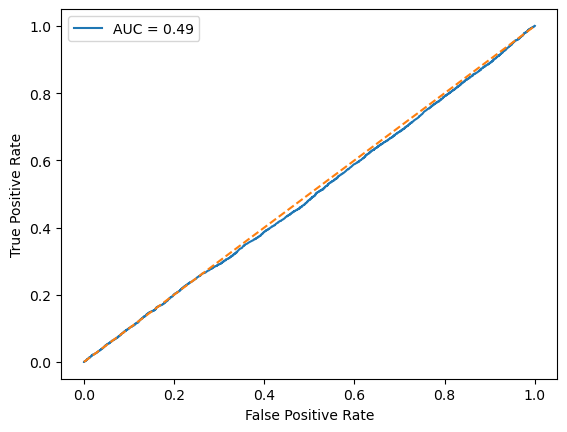

In [36]:
# Roc curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba_pos)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 5.4 Insights
1. Recall ~ 50, meaning the model is randomly guessing between 0 and 1
2. Accuracy ~ 50, further proves the prediction is a coin toss
3. Precision of 0 to 1 classes is 1:3, which is similar to total true values of 0 and 1. Conclusion - Model randomly predicts between 0 and 1
4. ROC-AUC score is 0.49, meaning it has no discriminatory power
5. ROC curve is approx along the baseline, which indicates FPR = TPR at every threshold value, further proves its predicting randomly

# 6. Conclusion
The analysis proves that transaction outcomes is not dependent of customer-facing variables. Factors like Price, Quantity and Payment Mode have no predictive correlation with success or failure. This suggests that transaction status is likely driven by external or backend factors, such as banking gateway latency or API timeouts, rather than user behavior